# Preliminary Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')

import matplotlib.dates as mdates
import re
from collections import Counter

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## Load datasets

In [2]:
import os
for f in os.listdir('clean'):
    size = os.path.getsize(f'clean/{f}')
    print(f"  {f}: {size/1024/1024:.1f} MB")
    

  bsky_repost_edgelist.csv: 102.3 MB
  truth_posts_clean.csv: 43.5 MB
  qwen_sample_sentiment.csv: 2.9 MB
  truth_reposts_clean.csv: 14.1 MB
  bsky_reposts_clean.csv: 880.1 MB
  bsky_comments_clean.csv: 590.7 MB
  bsky_posts_clean.csv: 861.7 MB
  truth_comments_clean.csv: 1.4 MB
  truth_repost_edgelist.csv: 0.9 MB


In [3]:
bsky = pd.read_csv('clean/bsky_posts_clean.csv', parse_dates=['created_at'])
truth = pd.read_csv('clean/truth_posts_clean.csv', parse_dates=['created_at'], dtype={'post_id': str})

print(f"Bluesky:      {len(bsky):,} posts")
print(f"Truth Social: {len(truth):,} posts")

Bluesky:      1,529,104 posts
Truth Social: 48,086 posts


In [4]:
# Align to overlapping date range (Feb 2023 - May 2026)
start = pd.Timestamp('2023-02-01', tz='UTC')
end = pd.Timestamp('2026-05-29', tz='UTC')

bsky['created_at'] = pd.to_datetime(bsky['created_at'], format='mixed', utc=True)
truth['created_at'] = pd.to_datetime(truth['created_at'], format='mixed', utc=True)

bsky = bsky[(bsky['created_at'] >= start) & (bsky['created_at'] <= end)]
truth = truth[(truth['created_at'] >= start) & (truth['created_at'] <= end)]

print(f"Aligned range: {start.date()} to {end.date()}")
print(f"Bluesky: {len(bsky):,} posts")
print(f"Truth Social: {len(truth):,} posts")

Aligned range: 2023-02-01 to 2026-05-29
Bluesky: 1,529,102 posts
Truth Social: 40,728 posts


## Dataset Composition


In [9]:
# BLUESKY COMPOSITION
bsky_comp = bsky.groupby('search_keyword').agg(
    posts=('post_uri', 'count'),
    unique_authors=('author_did', 'nunique'),
    mean_likes=('like_count', 'mean'),
    mean_reposts=('repost_count', 'mean'),
    mean_replies=('reply_count', 'mean'),
    earliest=('created_at', 'min'),
    latest=('created_at', 'max')
).sort_values('posts', ascending=False)

bsky_comp['mean_likes'] = bsky_comp['mean_likes'].round(1)
bsky_comp['mean_reposts'] = bsky_comp['mean_reposts'].round(1)
bsky_comp['mean_replies'] = bsky_comp['mean_replies'].round(1)

print("BLUESKY — Dataset Composition by Keyword")
print(bsky_comp.to_string())
print(f"\nTotal unique authors across all keywords: {bsky['author_did'].nunique():,}")

BLUESKY — Dataset Composition by Keyword
                         posts  unique_authors  mean_likes  mean_reposts  mean_replies                         earliest                              latest
search_keyword                                                                                                                                             
AI                      514430          170788         7.0           1.4           0.6        2023-02-01 00:26:47+00:00    2026-05-28 23:59:58.037000+00:00
ChatGPT                 373945          134697         8.9           1.6           0.6        2023-02-01 00:31:41+00:00    2026-05-28 23:59:56.292000+00:00
GenAI                   138090           39113        11.1           2.6           0.7 2023-04-15 16:52:53.006000+00:00    2026-05-28 23:58:14.543000+00:00
Midjourney              101630           10808         9.6           0.8           0.4 2023-02-01 04:26:02.002000+00:00    2026-05-28 23:45:37.459000+00:00
AI slop                

In [10]:
# TRUTH SOCIAL COMPOSITION
truth_comp = truth.groupby('hashtag').agg(
    posts=('post_id', 'count'),
    unique_authors=('author_id', 'nunique'),
    mean_likes=('like_count', 'mean'),
    mean_retruths=('retruth_count', 'mean'),
    mean_replies=('reply_count', 'mean'),
    earliest=('created_at', 'min'),
    latest=('created_at', 'max')
).sort_values('posts', ascending=False)

truth_comp['mean_likes'] = truth_comp['mean_likes'].round(1)
truth_comp['mean_retruths'] = truth_comp['mean_retruths'].round(1)
truth_comp['mean_replies'] = truth_comp['mean_replies'].round(1)

print("TRUTH SOCIAL — Dataset Composition by Hashtag")
print(truth_comp.to_string())
print(f"\nTotal unique authors across all hashtags: {truth['author_id'].nunique():,}")

TRUTH SOCIAL — Dataset Composition by Hashtag
                        posts  unique_authors  mean_likes  mean_retruths  mean_replies                         earliest                           latest
hashtag                                                                                                                                                 
AI                      23560            2503         1.6            0.7           0.2 2025-02-25 10:23:54.677000+00:00 2026-05-19 16:08:33.224000+00:00
BigTech                  6164            1026         6.6            2.9           0.6 2023-02-01 00:43:33.939000+00:00 2026-05-19 11:01:33.950000+00:00
ArtificialIntelligence   6013            1114         3.4            1.8           0.5 2023-02-01 01:13:42.888000+00:00 2026-05-19 15:59:59.594000+00:00
ChatGPT                  2627             923         1.7            0.9           0.3 2023-02-01 02:13:34.434000+00:00 2026-05-18 19:27:54.270000+00:00
project2025               969       

## Temporal Distribution



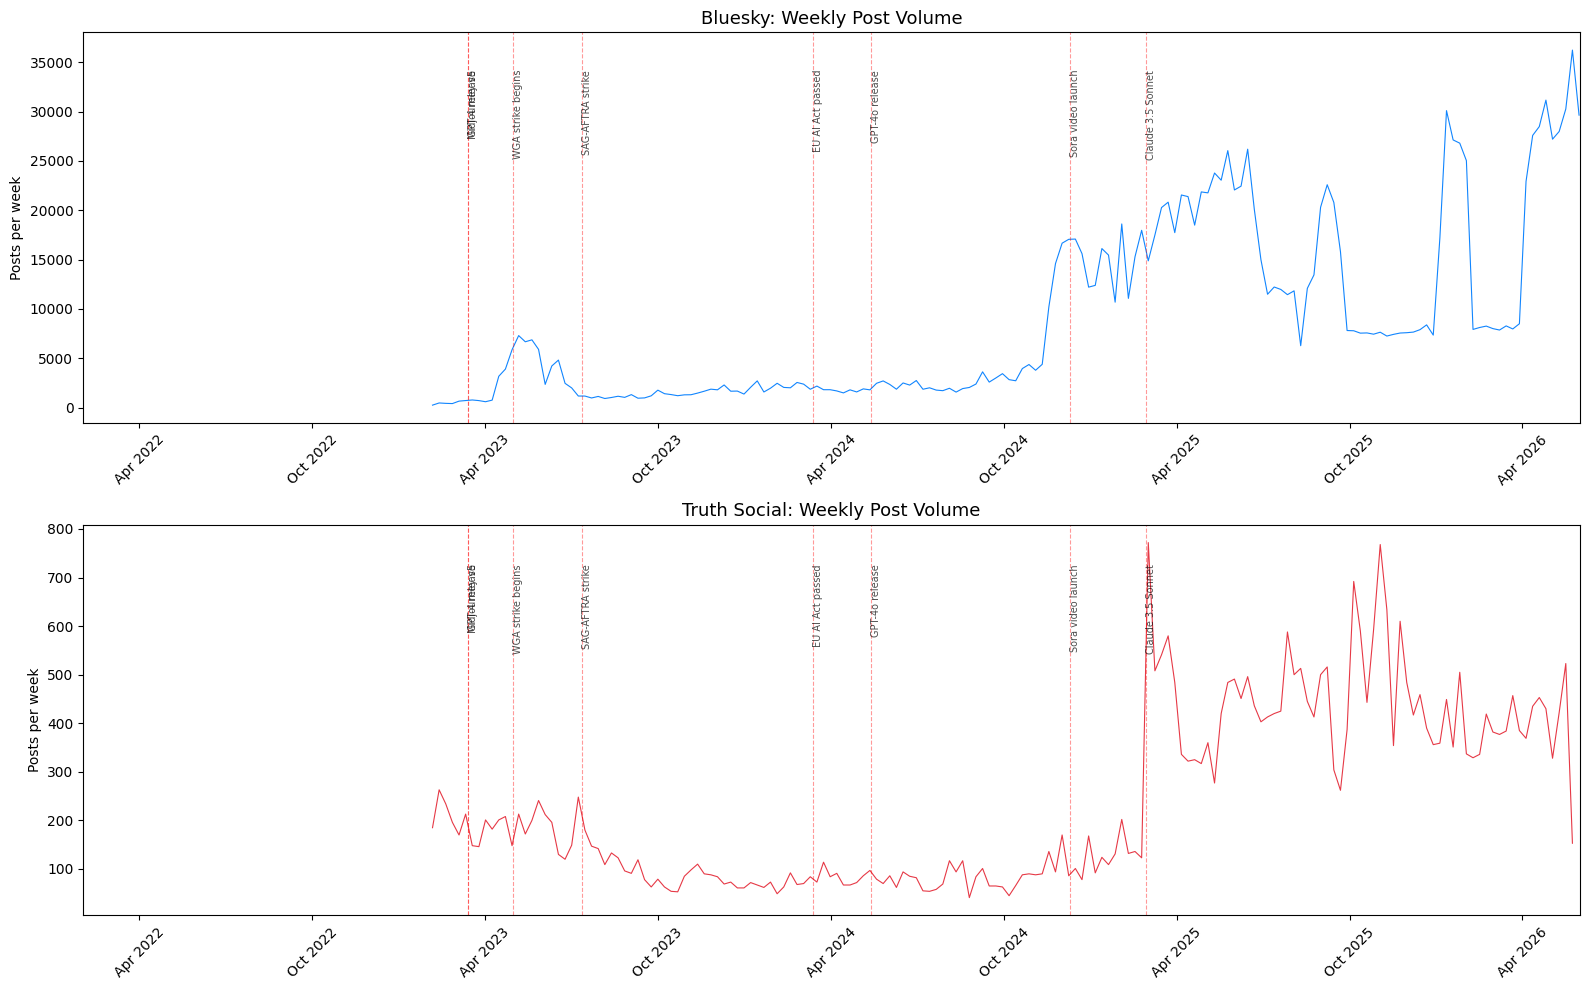

In [11]:
# KEY AI EVENTS 

bsky['created_at'] = pd.to_datetime(bsky['created_at'], format='mixed', utc=True)
truth['created_at'] = pd.to_datetime(truth['created_at'], format='mixed', utc=True)


AI_EVENTS = {
    '2022-11-30': 'ChatGPT launch',
    '2023-03-14': 'GPT-4 release',
    '2023-03-15': 'Midjourney v5',
    '2023-05-01': 'WGA strike begins',
    '2023-07-13': 'SAG-AFTRA strike',
    '2024-03-13': 'EU AI Act passed',
    '2024-05-13': 'GPT-4o release',
    '2024-12-09': 'Sora video launch',
    '2025-02-28': 'Claude 3.5 Sonnet',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# BLUESKY WEEKLY
bsky_weekly = bsky.set_index('created_at').resample('W').size()
ax1.plot(bsky_weekly.index, bsky_weekly.values, linewidth=0.8, color='#1185fe')
ax1.set_title('Bluesky: Weekly Post Volume', fontsize=13)
ax1.set_ylabel('Posts per week')

for date_str, label in AI_EVENTS.items():
    dt = pd.Timestamp(date_str, tz='UTC')
    if dt >= bsky_weekly.index.min():
        ax1.axvline(dt, color='red', alpha=0.4, linewidth=0.8, linestyle='--')
        ax1.text(dt, ax1.get_ylim()[1] * 0.9, label, rotation=90, fontsize=7, alpha=0.7, va='top')

# TRUTH SOCIAL WEEKLY
truth_weekly = truth.set_index('created_at').resample('W').size()
ax2.plot(truth_weekly.index, truth_weekly.values, linewidth=0.8, color='#e63946')
ax2.set_title('Truth Social: Weekly Post Volume', fontsize=13)
ax2.set_ylabel('Posts per week')

for date_str, label in AI_EVENTS.items():
    dt = pd.Timestamp(date_str, tz='UTC')
    if dt >= truth_weekly.index.min():
        ax2.axvline(dt, color='red', alpha=0.4, linewidth=0.8, linestyle='--')
        ax2.text(dt, ax2.get_ylim()[1] * 0.9, label, rotation=90, fontsize=7, alpha=0.7, va='top')

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

shared_xlim = (pd.Timestamp('2022-02-01', tz='UTC'), pd.Timestamp('2026-06-01', tz='UTC'))
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)

plt.tight_layout()
plt.show()

## Engagement Distributions



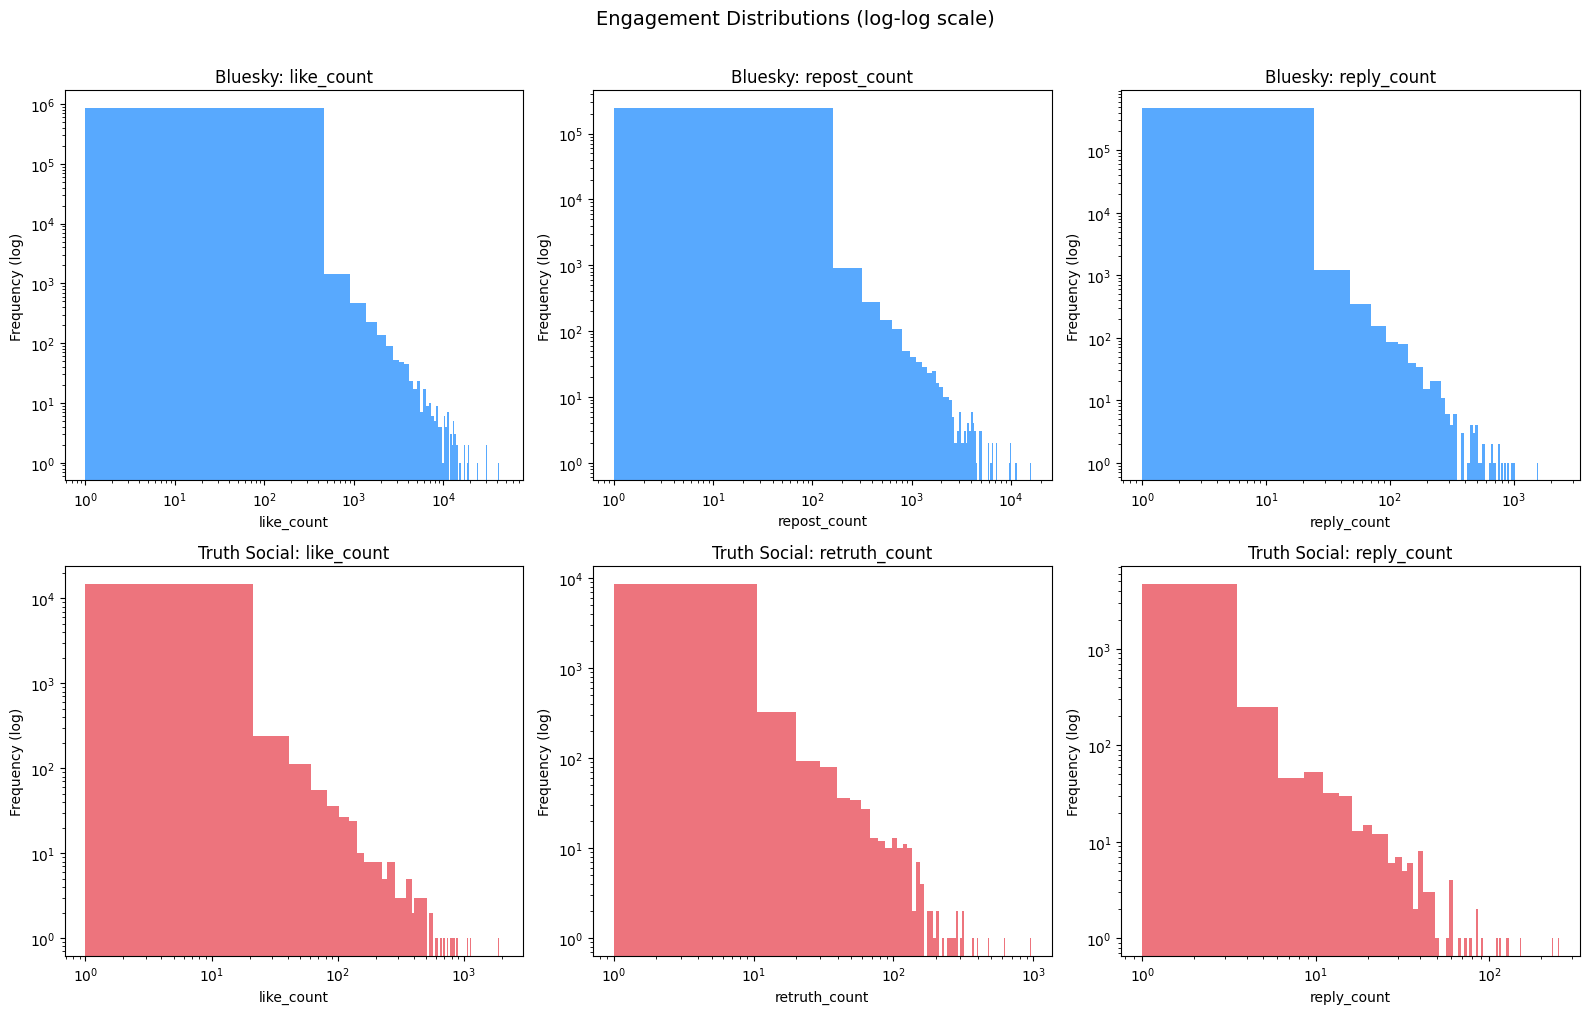

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# BLUESKY ENGAGEMENT DISTRIBUTIONS
for i, col in enumerate(['like_count', 'repost_count', 'reply_count']):
    ax = axes[0, i]
    data = bsky[col].clip(lower=0)
    data_nonzero = data[data > 0]
    if len(data_nonzero) > 0:
        ax.hist(data_nonzero, bins=100, alpha=0.7, color='#1185fe', edgecolor='none')
        ax.set_yscale('log')
        ax.set_xscale('log')
    ax.set_title(f'Bluesky: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency (log)')

# TRUTH SOCIAL ENGAGEMENT DISTRIBUTIONS
for i, col in enumerate(['like_count', 'retruth_count', 'reply_count']):
    ax = axes[1, i]
    data = truth[col].clip(lower=0)
    data_nonzero = data[data > 0]
    if len(data_nonzero) > 0:
        ax.hist(data_nonzero, bins=100, alpha=0.7, color='#e63946', edgecolor='none')
        ax.set_yscale('log')
        ax.set_xscale('log')
    ax.set_title(f'Truth Social: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency (log)')

plt.suptitle('Engagement Distributions (log-log scale)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ENGAGEMENT SUMMARY STATISTICS
print("BLUESKY ENGAGEMENT STATISTICS")
print(bsky[['like_count', 'repost_count', 'reply_count']].describe().round(2).to_string())

print(f"\nZero-engagement posts: {(bsky['like_count'] == 0).sum():,} ({(bsky['like_count'] == 0).mean()*100:.1f}%)")

print("\n\nTRUTH SOCIAL ENGAGEMENT STATISTICS")
print(truth[['like_count', 'retruth_count', 'reply_count']].describe().round(2).to_string())

print(f"\nZero-engagement posts: {(truth['like_count'] == 0).sum():,} ({(truth['like_count'] == 0).mean()*100:.1f}%)")

BLUESKY ENGAGEMENT STATISTICS
       like_count  repost_count  reply_count
count  1529102.00    1529102.00   1529102.00
mean         8.02          1.51         0.59
std        131.32         42.59         4.83
min          0.00          0.00         0.00
25%          0.00          0.00         0.00
50%          1.00          0.00         0.00
75%          3.00          0.00         1.00
max      45656.00      15921.00      2318.00

Zero-engagement posts: 667,145 (43.6%)


TRUTH SOCIAL ENGAGEMENT STATISTICS
       like_count  retruth_count  reply_count
count    40728.00       40728.00     40728.00
mean         2.71           1.22         0.33
std         26.98          10.48         3.00
min          0.00           0.00         0.00
25%          0.00           0.00         0.00
50%          0.00           0.00         0.00
75%          1.00           0.00         0.00
max       2020.00         960.00       253.00

Zero-engagement posts: 25,198 (61.9%)


## Author Activity Distribution



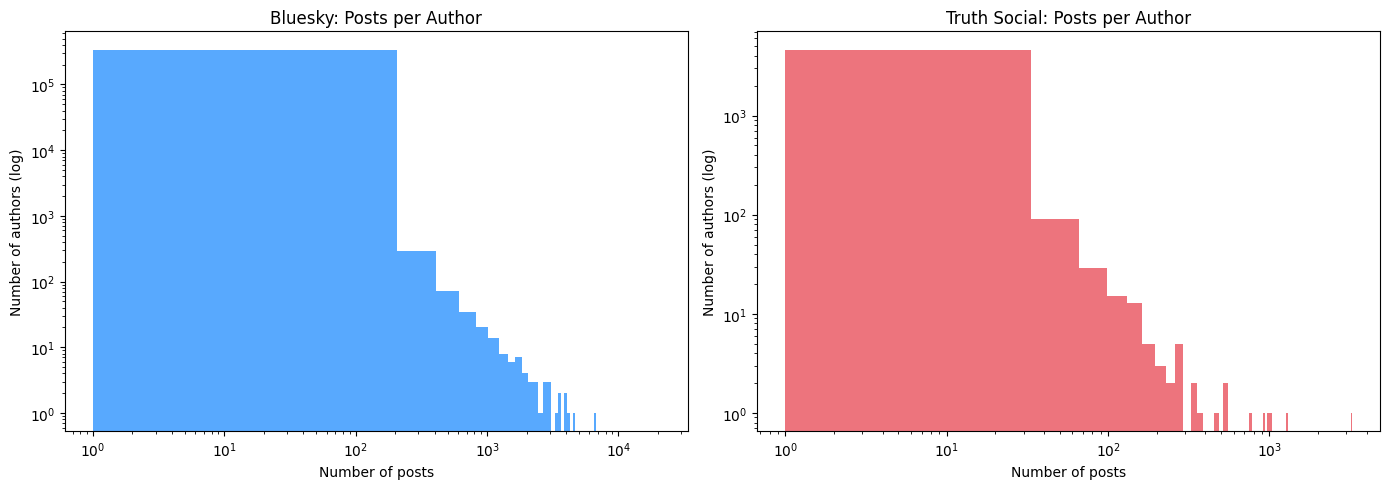

BLUESKY — Top 10 most prolific authors:
  llms.activitypub.awakari.com.ap.brid.gy: 20424 posts
  nowbreezing.ntw.app: 6679 posts
  chidambara09.bsky.social: 4648 posts
  ttaships.airminded.org: 4239 posts
  bigearthdata.ai: 4002 posts
  kai3690.bsky.social: 3893 posts
  jameswebbdiscovery.com: 3657 posts
  news-feed.bsky.social: 3579 posts
  ai-visions.bsky.social: 3451 posts
  drtimos.bsky.social: 3053 posts

Top 1% of authors produced 534,928 posts (35.0% of total)

TRUTH SOCIAL — Top 10 most prolific authors:
  USABuddhism: 3234 posts
  russianjewishkukla: 2710 posts
  yonhapinfomax: 1285 posts
  GaryInRedding: 1034 posts
  majorhewers: 980 posts
  Oldmanrant: 926 posts
  TonyCanteroSuarez: 745 posts
  soundsnerdy: 539 posts
  NaturalNews: 519 posts
  AIFanToken: 485 posts

Top 1% of authors produced 19,562 posts (48.0% of total)


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BLUESKY AUTHOR ACTIVITY
bsky_author_counts = bsky['author_did'].value_counts()
ax1.hist(bsky_author_counts.values, bins=100, alpha=0.7, color='#1185fe', edgecolor='none')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_title('Bluesky: Posts per Author')
ax1.set_xlabel('Number of posts')
ax1.set_ylabel('Number of authors (log)')

# TRUTH SOCIAL AUTHOR ACTIVITY
truth_author_counts = truth['author_id'].value_counts()
ax2.hist(truth_author_counts.values, bins=100, alpha=0.7, color='#e63946', edgecolor='none')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_title('Truth Social: Posts per Author')
ax2.set_xlabel('Number of posts')
ax2.set_ylabel('Number of authors (log)')

plt.tight_layout()
plt.show()

# TOP AUTHORS
print("BLUESKY — Top 10 most prolific authors:")
top_bsky = bsky_author_counts.head(10).reset_index()
top_bsky.columns = ['author_did', 'post_count']
# get handle for readability
for i, row in top_bsky.iterrows():
    handle = bsky[bsky['author_did'] == row['author_did']]['author_handle'].iloc[0]
    print(f"  {handle}: {row['post_count']} posts")

print(f"\nTop 1% of authors produced {bsky_author_counts.head(int(len(bsky_author_counts)*0.01)).sum():,} posts ({bsky_author_counts.head(int(len(bsky_author_counts)*0.01)).sum()/len(bsky)*100:.1f}% of total)")

print(f"\nTRUTH SOCIAL — Top 10 most prolific authors:")
top_truth = truth_author_counts.head(10).reset_index()
top_truth.columns = ['author_id', 'post_count']
for i, row in top_truth.iterrows():
    username = truth[truth['author_id'] == row['author_id']]['author_username'].iloc[0]
    print(f"  {username}: {row['post_count']} posts")

print(f"\nTop 1% of authors produced {truth_author_counts.head(int(len(truth_author_counts)*0.01)).sum():,} posts ({truth_author_counts.head(int(len(truth_author_counts)*0.01)).sum()/len(truth)*100:.1f}% of total)")

## Text Characteristics


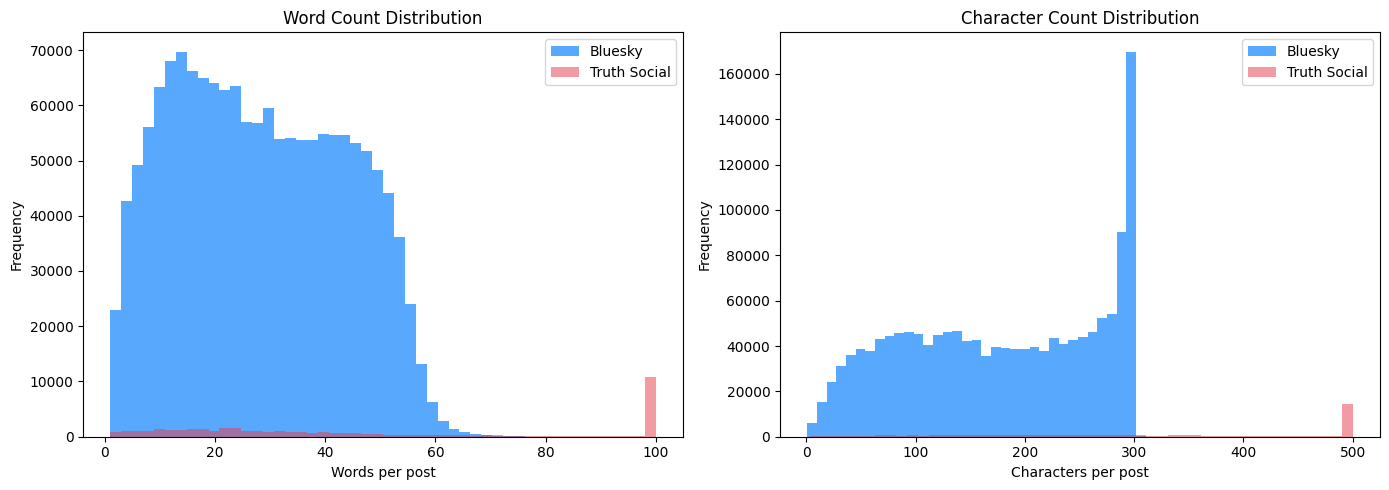

TEXT LENGTH STATISTICS

Bluesky:      median 27 words, mean 28.0 words
Truth Social: median 36 words, mean 85.1 words

Bluesky posts under 5 words:      65,629 (4.3%)
Truth Social posts under 5 words: 1,891 (4.6%)


In [15]:
# TEXT LENGTH DISTRIBUTIONS
bsky['word_count'] = bsky['text'].str.split().str.len()
truth['word_count'] = truth['text'].str.split().str.len()
bsky['char_count'] = bsky['text'].str.len()
truth['char_count'] = truth['text'].str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(bsky['word_count'].clip(upper=100), bins=50, alpha=0.7, color='#1185fe', edgecolor='none', label='Bluesky')
ax1.hist(truth['word_count'].clip(upper=100), bins=50, alpha=0.5, color='#e63946', edgecolor='none', label='Truth Social')
ax1.set_title('Word Count Distribution')
ax1.set_xlabel('Words per post')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(bsky['char_count'].clip(upper=500), bins=50, alpha=0.7, color='#1185fe', edgecolor='none', label='Bluesky')
ax2.hist(truth['char_count'].clip(upper=500), bins=50, alpha=0.5, color='#e63946', edgecolor='none', label='Truth Social')
ax2.set_title('Character Count Distribution')
ax2.set_xlabel('Characters per post')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

print("TEXT LENGTH STATISTICS")
print(f"\nBluesky:      median {bsky['word_count'].median():.0f} words, mean {bsky['word_count'].mean():.1f} words")
print(f"Truth Social: median {truth['word_count'].median():.0f} words, mean {truth['word_count'].mean():.1f} words")

print(f"\nBluesky posts under 5 words:      {(bsky['word_count'] < 5).sum():,} ({(bsky['word_count'] < 5).mean()*100:.1f}%)")
print(f"Truth Social posts under 5 words: {(truth['word_count'] < 5).sum():,} ({(truth['word_count'] < 5).mean()*100:.1f}%)")

## Keyword Overlap Analysis



In [16]:
# check how many posts appear under multiple keywords (Bluesky)
bsky_post_keywords = bsky.groupby('post_uri')['search_keyword'].apply(list).reset_index()
bsky_post_keywords['n_keywords'] = bsky_post_keywords['search_keyword'].apply(len)
multi_keyword = bsky_post_keywords[bsky_post_keywords['n_keywords'] > 1]

print("BLUESKY KEYWORD OVERLAP")
print(f"  Posts appearing under 1 keyword:  {(bsky_post_keywords['n_keywords'] == 1).sum():,}")
print(f"  Posts appearing under 2+ keywords: {len(multi_keyword):,}")

if len(multi_keyword) > 0:
    print(f"\n  Most common overlapping pairs:")
    from itertools import combinations
    pair_counts = Counter()
    for kws in multi_keyword['search_keyword']:
        for pair in combinations(sorted(set(kws)), 2):
            pair_counts[pair] += 1
    for pair, count in pair_counts.most_common(10):
        print(f"    {pair[0]} + {pair[1]}: {count:,}")

BLUESKY KEYWORD OVERLAP
  Posts appearing under 1 keyword:  1,529,102
  Posts appearing under 2+ keywords: 0


## MBFC examination

In [21]:

def extract_urls(text):
    # Extract all URLs from text
    if pd.isna(text):
        return []
    return re.findall(r'https?://[^\s<>"{}|\\^`\[\]]+', str(text))


def extract_domain(url):
    # Extract domain from URL, stripping www
    try:
        from urllib.parse import urlparse
        parsed = urlparse(url)
        domain = parsed.netloc.lower()
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain
    except:
        return None


# BLUESKY URLS
bsky['urls'] = bsky['text'].apply(extract_urls)
bsky['url_count'] = bsky['urls'].apply(len)
bsky_has_url = bsky[bsky['url_count'] > 0]

all_bsky_urls = [url for urls in bsky_has_url['urls'] for url in urls]
bsky_domains = [extract_domain(u) for u in all_bsky_urls]
bsky_domain_counts = Counter([d for d in bsky_domains if d])

print("BLUESKY URLS")
print(f"  Posts with URLs: {len(bsky_has_url):,} ({len(bsky_has_url)/len(bsky)*100:.1f}%)")
print(f"  Total URLs:      {len(all_bsky_urls):,}")
print(f"  Unique domains:  {len(bsky_domain_counts):,}")
print(f"\n  Top 20 domains:")
for domain, count in bsky_domain_counts.most_common(20):
    print(f"    {domain}: {count:,}")

# TRUTH SOCIAL URLS
truth['urls'] = truth['text'].apply(extract_urls)
truth['url_count'] = truth['urls'].apply(len)
truth_has_url = truth[truth['url_count'] > 0]

all_truth_urls = [url for urls in truth_has_url['urls'] for url in urls]
truth_domains = [extract_domain(u) for u in all_truth_urls]
truth_domain_counts = Counter([d for d in truth_domains if d])

print(f"\n\nTRUTH SOCIAL URLS")
print(f"  Posts with URLs: {len(truth_has_url):,} ({len(truth_has_url)/len(truth)*100:.1f}%)")
print(f"  Total URLs:      {len(all_truth_urls):,}")
print(f"  Unique domains:  {len(truth_domain_counts):,}")
print(f"\n  Top 20 domains:")
for domain, count in truth_domain_counts.most_common(20):
    print(f"    {domain}: {count:,}")









BLUESKY URLS
  Posts with URLs: 119,857 (7.8%)
  Total URLs:      131,636
  Unique domains:  11,843

  Top 20 domains:
    arxiv.org: 6,616
    t.co: 3,895
    amzn.to: 3,594
    chatgpt.com: 3,473
    u2m.io: 3,217
    bit.ly: 2,512
    news.ycombinator.com: 2,487
    buff.ly: 2,269
    medium.com: 1,590
    community.openai.com: 1,477
    fundspec.io: 1,460
    youtube.com: 1,389
    zip358.com: 1,252
    github.com: 1,225
    tinyurl.com: 1,203
    theverge.com: 1,088
    techcrunch.com: 1,020
    gigazine.net: 925
    youtu.be: 856
    aepprotocol.xyz: 814


TRUTH SOCIAL URLS
  Posts with URLs: 24,526 (60.2%)
  Total URLs:      28,343
  Unique domains:  2,276

  Top 20 domains:
    youtube.com: 2,683
    truthsocial.com: 2,396
    open.spotify.com: 1,481
    youtu.be: 1,466
    en.infomaxai.com: 1,299
    rumble.com: 1,126
    fatherlyadviceandrants.com: 1,034
    soundsnerdy.com: 459
    sonovamusicrecords.com: 441
    zerohedge.com: 392
    naturalnews.com: 383
    x.com: 333
   

In [22]:

# URL SHORTENERS 

shorteners = {'t.co', 'bit.ly', 'tinyurl.com', 'ow.ly', 'buff.ly', 'dlvr.it', 'is.gd', 'goo.gl'}

bsky_shortened = sum(1 for d in bsky_domains if d in shorteners)
truth_shortened = sum(1 for d in truth_domains if d in shorteners)

print("URL SHORTENERS (will need resolving for MBFC matching)")
print(f"  Bluesky:      {bsky_shortened:,} shortened URLs ({bsky_shortened/max(len(all_bsky_urls),1)*100:.1f}%)")
print(f"  Truth Social: {truth_shortened:,} shortened URLs ({truth_shortened/max(len(all_truth_urls),1)*100:.1f}%)")





URL SHORTENERS (will need resolving for MBFC matching)
  Bluesky:      10,880 shortened URLs (8.3%)
  Truth Social: 284 shortened URLs (1.0%)


In [24]:
print(bsky.columns.tolist())


['post_uri', 'post_cid', 'text', 'created_at', 'reply_count', 'repost_count', 'like_count', 'quote_count', 'search_keyword', 'language', 'has_images', 'image_count', 'has_video', 'author_did', 'author_handle', 'author_display_name', 'author_avatar', 'author_description', 'platform', 'word_count', 'char_count', 'urls', 'url_count']


## Cross-Platform Comparison Summary



In [1]:
print("CROSS-PLATFORM COMPARISON")

metrics = {
    'Metric': [
        'Total posts',
        'Unique authors',
        'Date range start',
        'Date range end',
        'Collection method',
        'Median word count',
        'Mean likes per post',
        'Mean reposts per post',
        'Mean replies per post',
        'Posts with URLs',
        'Zero-engagement posts',
    ],
    'Bluesky': [
        f"{len(bsky):,}",
        f"{bsky['author_did'].nunique():,}",
        str(bsky['created_at'].min().date()),
        str(bsky['created_at'].max().date()),
        'Keyword search (full text)',
        f"{bsky['word_count'].median():.0f}",
        f"{bsky['like_count'].mean():.1f}",
        f"{bsky['repost_count'].mean():.1f}",
        f"{bsky['reply_count'].mean():.1f}",
        f"{len(bsky_has_url):,} ({len(bsky_has_url)/len(bsky)*100:.1f}%)",
        f"{(bsky['like_count']==0).sum():,} ({(bsky['like_count']==0).mean()*100:.1f}%)",
    ],
    'Truth Social': [
        f"{len(truth):,}",
        f"{truth['author_id'].nunique():,}",
        str(truth['created_at'].min().date()),
        str(truth['created_at'].max().date()),
        'Hashtag timeline (API)',
        f"{truth['word_count'].median():.0f}",
        f"{truth['like_count'].mean():.1f}",
        f"{truth['retruth_count'].mean():.1f}",
        f"{truth['reply_count'].mean():.1f}",
        f"{len(truth_has_url):,} ({len(truth_has_url)/len(truth)*100:.1f}%)",
        f"{(truth['like_count']==0).sum():,} ({(truth['like_count']==0).mean()*100:.1f}%)",
    ]
}

comparison_df = pd.DataFrame(metrics)
print(comparison_df.to_string(index=False))

CROSS-PLATFORM COMPARISON
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


NameError: name 'bsky' is not defined

## Edge list for Network analysis

In [27]:
# Bluesky repost edge list
bsky_reposts = pd.read_csv('clean/bsky_reposts_clean.csv')
bsky_posts = pd.read_csv('clean/bsky_posts_clean.csv', usecols=['post_uri', 'author_did'])

bsky_edges = bsky_reposts.merge(bsky_posts, on='post_uri', how='inner')
bsky_edges = (bsky_edges
    .groupby(['author_did', 'reposted_by_did'])
    .size()
    .reset_index(name='weight')
    .rename(columns={'author_did': 'source', 'reposted_by_did': 'target'}))

print(f"Bluesky edges: {len(bsky_edges):,}")
print(f"Unique sources: {bsky_edges['source'].nunique():,}")
print(f"Unique targets: {bsky_edges['target'].nunique():,}")
bsky_edges.to_csv('clean/bsky_repost_edgelist.csv', index=False)


Bluesky edges: 1,577,684
Unique sources: 42,845
Unique targets: 360,210


In [29]:
print(bsky_edges.head(10).to_string())
print(f"\nTop edges by weight:")
print(bsky_edges.sort_values('weight', ascending=False).head(10).to_string())

                             source                            target  weight
0  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2bngtbjbuisgz74oblcdvhfj       1
1  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2cadvbwpkxtuvmv2gpy5laml       1
2  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2wfmbc2rbodcexiiyms4yh6x       1
3  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:46haijs5rxtkat6bijis2ltd       1
4  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:53xy3x3zo33lg6ukj2xuefye       1
5  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:5sxudf4p3inc7zwecaivoiwu       1
6  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:66wvnez7xecq2a3jvsigxwfx       1
7  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:6evenmfi4wjnrtos5wadaar6       1
8  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:6i6nib4vlqmhpspfww5n2tjd       1
9  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:6kdg7avq4vqjgvciwdp5eb6w       1

Top edges by weight:
                                   source                            target  weight
1161467  did:plc:rivbee6mfjetayu6fvm

In [28]:
# Truth Social repost edge list
truth_reposts = pd.read_csv('clean/truth_reposts_clean.csv', dtype={'post_id': str, 'retruthed_by_id': str})
truth_posts = pd.read_csv('clean/truth_posts_clean.csv', usecols=['post_id', 'author_id'], dtype={'post_id': str, 'author_id': str})
truth_edges = truth_reposts.merge(truth_posts, on='post_id', how='inner')
truth_edges = (truth_edges
    .groupby(['author_id', 'retruthed_by_id'])
    .size()
    .reset_index(name='weight')
    .rename(columns={'author_id': 'source', 'retruthed_by_id': 'target'}))
print(f"Truth Social edges: {len(truth_edges):,}")
print(f"Unique sources: {truth_edges['source'].nunique():,}")
print(f"Unique targets: {truth_edges['target'].nunique():,}")
truth_edges.to_csv('clean/truth_repost_edgelist.csv', index=False)

Truth Social edges: 24,056
Unique sources: 901
Unique targets: 15,432


In [30]:
print(truth_edges.head(10).to_string())
print(f"\nTop edges by weight:")
print(truth_edges.sort_values('weight', ascending=False).head(10).to_string())

               source              target  weight
0  107771700550828156  107820210902767692       1
1  107771700550828156  107827281735305647       2
2  107771700550828156  107834165142662048       1
3  107771700550828156  107834266066563239       1
4  107771700550828156  107834365906847579       1
5  107771700550828156  107834383283650212       1
6  107771700550828156  107834391789607246       1
7  107771700550828156  107835405807831667       1
8  107771700550828156  107835497296411048       1
9  107771700550828156  107835596857501674       1

Top edges by weight:
                   source              target  weight
13967  107850387648658570  107855592531667456     122
13948  107850387648658570  107849167490321059      99
16611  108120503597604340  108120503597604340      82
21356  108806895322598820  107834602913823681      82
23569  113850276758543495  107843144870448168      80
11801  107841479228866470  107843144870448168      74
12173  107842320319303952  107842320319303952     

In [32]:
!cp clean/bsky_repost_edgelist.csv "$HOME/Library/CloudStorage/OneDrive-NortheasternUniversity/Dissertation/Data Collection/"
!cp clean/truth_repost_edgelist.csv "$HOME/Library/CloudStorage/OneDrive-NortheasternUniversity/Dissertation/Data Collection/"

## Engagement

In [5]:
bsky = pd.read_csv('clean/bsky_posts_clean.csv')

# Option 1: Engagement percentile filtering
bsky['total_engagement'] = bsky['like_count'] + bsky['repost_count'] + bsky['reply_count']

for pct in [50, 75, 90, 95]:
    threshold = bsky['total_engagement'].quantile(pct / 100)
    n = (bsky['total_engagement'] >= threshold).sum()
    print(f"  Top {100-pct}% (engagement >= {threshold:.0f}): {n:,} posts")

print(f"\n  Posts with zero engagement: {(bsky['total_engagement'] == 0).sum():,} ({(bsky['total_engagement'] == 0).mean()*100:.1f}%)")
print(f"  Median engagement: {bsky['total_engagement'].median():.0f}")
print(f"  Mean engagement: {bsky['total_engagement'].mean():.1f}")

  Top 50% (engagement >= 1): 991,163 posts
  Top 25% (engagement >= 4): 396,098 posts
  Top 10% (engagement >= 12): 159,268 posts
  Top 5% (engagement >= 25): 76,557 posts

  Posts with zero engagement: 537,941 (35.2%)
  Median engagement: 1
  Mean engagement: 10.1
